In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 日本語フォント設定
# plt.rcParams["font.family"] = "DejaVu Sans"
sns.set_style("whitegrid")
plt.style.use("default")

In [ ]:
# 日本語フォント設定
matplotlib.rc("font", family="IPAexGothic")

In [ ]:
# 現在の最大表示列数の出力
pd.get_option("display.max_columns")

150

In [ ]:
# 最大表示列数の指定
pd.set_option("display.max_columns", 150)

In [ ]:
# 現在の最大表示行数の出力
pd.get_option("display.max_rows")

40

In [ ]:
# 最大表示行数の指定
pd.set_option("display.max_rows", 40)

In [ ]:
# データの読み込み
results_df = pd.read_csv("data/results.csv")
results_df.head()

,年,月,日,レース場番号,レース番号,距離,天候,風向,風速,波高,単勝_艇番,単勝_払戻金,複勝1着_艇番,複勝1着_払戻金,複勝2着_艇番,複勝2着_払戻金,2連単_艇番,2連単_払戻金,2連単_人気,2連複_艇番,2連複_払戻金,2連複_人気,拡連複1_艇番,拡連複1_払戻金,拡連複1_人気,拡連複2_艇番,拡連複2_払戻金,拡連複2_人気,拡連複3_艇番,拡連複3_払戻金,拡連複3_人気,3連単_艇番,3連単_払戻金,3連単_人気,3連複_艇番,3連複_払戻金,3連複_人気,着順,選手登番,艇番,モーター番号,ボート番号,展示,進入,スタートタイミング,レースタイム
0,2025,1,1,24,1,1800,晴,北西,2,1,1.0,160.0,1.0,130.0,2.0,150.0,1-2,250.0,1.0,1-2,230.0,1.0,1-2,140.0,2.0,1-4,130.0,1.0,2-4,260.0,5.0,1-2-4,910.0,2.0,1-2-4,440.0,2.0,1,3527,1,57,59,6.87,1.0,0.13,1.48.5
1,2025,1,1,24,1,1800,晴,北西,2,1,1.0,160.0,1.0,130.0,2.0,150.0,1-2,250.0,1.0,1-2,230.0,1.0,1-2,140.0,2.0,1-4,130.0,1.0,2-4,260.0,5.0,1-2-4,910.0,2.0,1-2-4,440.0,2.0,2,4603,2,29,53,6.82,2.0,0.10,1.49.1
2,2025,1,1,24,1,1800,晴,北西,2,1,1.0,160.0,1.0,130.0,2.0,150.0,1-2,250.0,1.0,1-2,230.0,1.0,1-2,140.0,2.0,1-4,130.0,1.0,2-4,260.0,5.0,1-2-4,910.0,2.0,1-2-4,440.0,2.0,4,3843,3,43,48,6.90,3.0,0.14,1.52.0
3,2025,1,1,24,1,1800,晴,北西,2,1,1.0,160.0,1.0,130.0,2.0,150.0,1-2,250.0,1.0,1-2,230.0,1.0,1-2,140.0,2.0,1-4,130.0,1.0,2-4,260.0,5.0,1-2-4,910.0,2.0,1-2-4,440.0,2.0,3,5048,4,40,51,6.86,5.0,0.16,1.50.7
4,2025,1,1,24,1,1800,晴,北西,2,1,1.0,160.0,1.0,130.0,2.0,150.0,1-2,250.0,1.0,1-2,230.0,1.0,1-2,140.0,2.0,1-4,130.0,1.0,2-4,260.0,5.0,1-2-4,910.0,2.0,1-2-4,440.0,2.0,6,5335,5,65,65,6.91,6.0,0.27,NaN


In [ ]:
# "年" "月" "日" 列から日付列を作成
# 年,月,日を結合して日付型に変換
results_df.insert(
    0,
    "開催日",
    pd.to_datetime(
        results_df["年"].astype(str)
        + "-"
        + results_df["月"].astype(str)
        + "-"
        + results_df["日"].astype(str)
    ),
)

In [ ]:
# "年" "月" "日" "レース場番号" "レース番号"からレースID列を作成
results_df.insert(
    1,
    "レースID",
    results_df["年"].astype(str)
    + results_df["月"].astype(str).str.zfill(2)
    + results_df["日"].astype(str).str.zfill(2)
    + results_df["レース場番号"].astype(str).str.zfill(2)
    + results_df["レース番号"].astype(str).str.zfill(2),
)

In [ ]:
# "年" "月" "日" 列の削除
results_df = results_df.drop(columns=["年", "月", "日"])

In [ ]:
# 不要カラムを削除
import re

drop_columns = [
    "複勝1着_艇番",
    "複勝1着_払戻金",
    "複勝2着_艇番",
    "複勝2着_払戻金",
    "2連単_艇番",
    "2連単_払戻金",
    "2連単_人気",
    "2連複_艇番",
    "2連複_払戻金",
    "2連複_人気",
    "拡連複1_艇番",
    "拡連複1_払戻金",
    "拡連複1_人気",
    "拡連複2_艇番",
    "拡連複2_払戻金",
    "拡連複2_人気",
    "拡連複3_艇番",
    "拡連複3_払戻金",
    "拡連複3_人気",
    "3連単_艇番",
    "3連単_払戻金",
    "3連単_人気",
    "3連複_艇番",
    "3連複_払戻金",
    "3連複_人気",
]

results_df = results_df.drop(columns=drop_columns)

In [ ]:
# レースタイム 分.秒.ms 形式を秒に変換する関数
def time_to_seconds(time_str):
    try:
        minutes, seconds, milli100seconds = time_str.split(".")
        total_seconds = int(minutes) * 60 + float(seconds) + float(milli100seconds) / 10
        return total_seconds
    except:
        return np.nan


# レースタイム列を秒に変換
results_df["レースタイム秒"] = results_df["レースタイム"].apply(time_to_seconds)

In [ ]:
# レースタイム列を削除
results_df = results_df.drop(columns=["レースタイム"])

In [ ]:
# 距離が1800mのレースデータにフィルタリング
results_df = results_df[results_df["距離"] == 1800]

In [ ]:
# 着順が "F", "S0", "S1", "S2", "L0", "L1", "K0", "K1" のデータはフィルタリング
results_df = results_df[
    ~results_df["着順"].isin(["F", "S0", "S1", "S2", "L0", "L1", "K0", "K1"])
]
# 着順を整数に変換
results_df["着順"] = results_df["着順"].astype(int)

In [ ]:
# スタートタイミングを数値に変換
results_df["スタートタイミング"] = pd.to_numeric(
    results_df["スタートタイミング"], errors="coerce"
)

In [ ]:
results_df.describe()

,開催日,レース場番号,レース番号,距離,風速,波高,単勝_艇番,単勝_払戻金,着順,選手登番,艇番,モーター番号,ボート番号,進入,スタートタイミング,レースタイム秒
count,260738,260738.000000,260738.000000,260738.0,260738.000000,260738.000000,260617.000000,260617.00000,260738.000000,260738.000000,260738.000000,260738.000000,260738.000000,260738.000000,260738.000000,197801.000000
mean,2025-05-29 20:08:39.031364608,12.567742,6.456961,1800.0,2.772055,2.436718,2.080540,405.58820,3.468927,4428.316970,3.498585,39.866015,43.143393,3.494005,0.162749,112.995280
min,2025-01-01 00:00:00,1.000000,1.000000,1800.0,0.000000,0.000000,1.000000,100.00000,1.000000,2014.000000,1.000000,1.000000,1.000000,1.000000,0.000000,105.200000
25%,2025-03-17 00:00:00,7.000000,3.000000,1800.0,2.000000,1.000000,1.000000,130.00000,2.000000,3996.000000,2.000000,23.000000,26.000000,2.000000,0.110000,111.000000
50%,2025-06-02 00:00:00,12.000000,6.000000,1800.0,3.000000,2.000000,1.000000,200.00000,3.000000,4439.000000,3.000000,39.000000,43.000000,3.000000,0.160000,112.700000
75%,2025-08-10 00:00:00,19.000000,9.000000,1800.0,4.000000,3.000000,3.000000,430.00000,5.000000,4932.000000,5.000000,56.000000,60.000000,5.000000,0.200000,114.400000
max,2025-10-25 00:00:00,24.000000,12.000000,1800.0,12.000000,20.000000,6.000000,41150.00000,6.000000,5420.000000,6.000000,90.000000,95.000000,6.000000,0.980000,149.300000
std,NaN,6.912702,3.452693,0.0,1.654204,1.875269,1.445479,682.27385,1.697484,585.289415,1.707977,19.952738,20.199589,1.705963,0.071211,3.002645


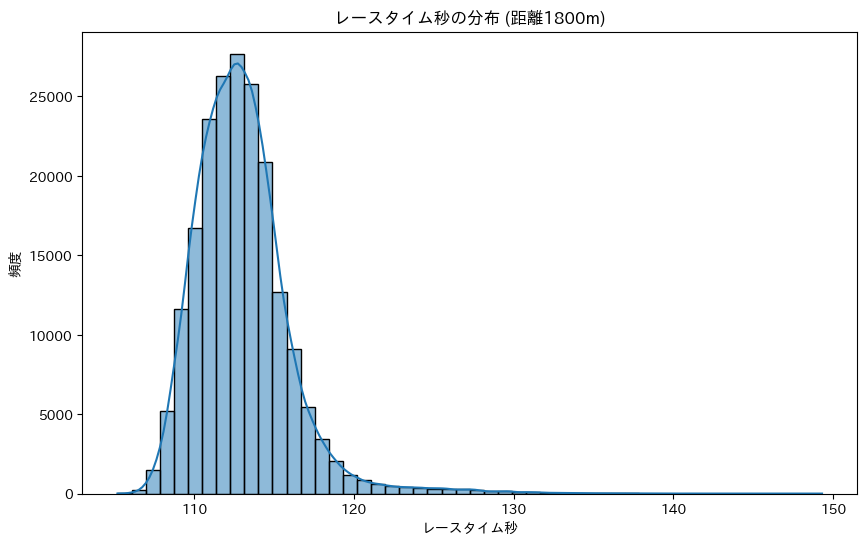

In [ ]:
# レースタイム秒のヒストグラムをプロット
plt.figure(figsize=(10, 6))
sns.histplot(results_df["レースタイム秒"].dropna(), bins=50, kde=True)
plt.title("レースタイム秒の分布 (距離1800m)")
plt.xlabel("レースタイム秒")
plt.ylabel("頻度")
plt.show()

In [ ]:
results_df.head(10)

,開催日,レースID,レース場番号,レース番号,距離,天候,風向,風速,波高,単勝_艇番,単勝_払戻金,着順,選手登番,艇番,モーター番号,ボート番号,展示,進入,スタートタイミング,レースタイム秒
0,2025-01-01,202501012401,24,1,1800,晴,北西,2,1,1.0,160.0,1,3527,1,57,59,6.87,1.0,0.13,108.5
1,2025-01-01,202501012401,24,1,1800,晴,北西,2,1,1.0,160.0,2,4603,2,29,53,6.82,2.0,0.10,109.1
2,2025-01-01,202501012401,24,1,1800,晴,北西,2,1,1.0,160.0,4,3843,3,43,48,6.90,3.0,0.14,112.0
3,2025-01-01,202501012401,24,1,1800,晴,北西,2,1,1.0,160.0,3,5048,4,40,51,6.86,5.0,0.16,110.7
4,2025-01-01,202501012401,24,1,1800,晴,北西,2,1,1.0,160.0,6,5335,5,65,65,6.91,6.0,0.27,NaN
5,2025-01-01,202501012401,24,1,1800,晴,北西,2,1,1.0,160.0,5,3906,6,75,75,6.88,4.0,0.18,NaN
6,2025-01-01,202501012402,24,2,1800,晴,北西,2,1,2.0,130.0,2,4004,1,60,73,6.84,1.0,0.07,110.5
7,2025-01-01,202501012402,24,2,1800,晴,北西,2,1,2.0,130.0,1,4315,2,62,27,6.75,2.0,0.11,109.0
8,2025-01-01,202501012402,24,2,1800,晴,北西,2,1,2.0,130.0,3,5129,3,58,64,6.95,3.0,0.11,110.9
9,2025-01-01,202501012402,24,2,1800,晴,北西,2,1,2.0,130.0,6,3722,4,19,30,6.89,4.0,0.17,NaN


In [ ]:
# 選手登番, 艇番ごとの平均レースタイム秒, レースタイム秒の標準偏差を計算
avg_times_df = (
    results_df.groupby(["選手登番", "艇番"])["レースタイム秒"]
    .agg(["mean", "std"])
    .reset_index()
)
avg_times_df = avg_times_df.rename(
    columns={"mean": "平均レースタイム秒", "std": "レースタイム秒標準偏差"}
)
avg_times_df.head(10)

,選手登番,艇番,平均レースタイム秒,レースタイム秒標準偏差
0,2014,1,111.675000,2.556528
1,2014,2,113.433333,4.080850
2,2014,3,113.240000,1.828387
3,2014,4,113.166667,2.891943
4,2014,5,113.250000,0.777817
5,2014,6,113.600000,2.404163
6,2538,1,113.229412,1.483562
7,2538,2,114.342105,1.904473
8,2538,3,115.209091,1.640399
9,2538,4,115.208333,1.859843


In [ ]:
# 選手登番, 艇番ごとの出走回数, 1-6着回数を計算
finish_stats_df = (
    results_df.groupby(["選手登番", "艇番"])["着順"]
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)
finish_stats_df = finish_stats_df.rename(
    columns={
        1: "1着回数",
        2: "2着回数",
        3: "3着回数",
        4: "4着回数",
        5: "5着回数",
        6: "6着回数",
    }
)
finish_stats_df["出走回数"] = finish_stats_df[
    ["1着回数", "2着回数", "3着回数", "4着回数", "5着回数", "6着回数"]
].sum(axis=1)

# 選手登番, 艇番ごとの出走回数, 1-6着率を計算
for i in range(1, 7):
    finish_stats_df[f"{i}着率"] = (
        finish_stats_df[f"{i}着回数"] / finish_stats_df["出走回数"]
    )

In [ ]:
# 選手登番毎の総出走回数
total_races_df = finish_stats_df.groupby("選手登番")["出走回数"].sum().reset_index()
total_races_df = total_races_df.rename(columns={"出走回数": "総出走回数"})
total_races_df.head(10)

,選手登番,総出走回数
0,2014,26
1,2538,133
2,2878,198
3,3024,171
4,3054,130
5,3070,69
6,3072,155
7,3075,172
8,3081,127
9,3105,167


In [ ]:
# total_races_dfをfinish_stats_dfに結合
finish_stats_df = finish_stats_df.merge(total_races_df, on="選手登番", how="left")

In [ ]:
finish_stats_df.head(100)

,選手登番,艇番,1着回数,2着回数,3着回数,4着回数,5着回数,6着回数,出走回数,1着率,2着率,3着率,4着率,5着率,6着率,総出走回数
0,2014,1,1,1,1,0,1,1,5,0.200000,0.200000,0.200000,0.000000,0.200000,0.200000,26
1,2014,2,0,1,1,0,0,1,3,0.000000,0.333333,0.333333,0.000000,0.000000,0.333333,26
2,2014,3,0,1,2,1,1,2,7,0.000000,0.142857,0.285714,0.142857,0.142857,0.285714,26
3,2014,4,0,2,0,0,2,0,4,0.000000,0.500000,0.000000,0.000000,0.500000,0.000000,26
4,2014,5,0,0,1,1,0,2,4,0.000000,0.000000,0.250000,0.250000,0.000000,0.500000,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,3175,6,0,1,4,2,6,7,20,0.000000,0.050000,0.200000,0.100000,0.300000,0.350000,133
96,3176,1,12,7,1,3,2,3,28,0.428571,0.250000,0.035714,0.107143,0.071429,0.107143,168
97,3176,2,3,8,3,5,7,3,29,0.103448,0.275862,0.103448,0.172414,0.241379,0.103448,168
98,3176,3,0,3,8,7,8,4,30,0.000000,0.100000,0.266667,0.233333,0.266667,0.133333,168


In [ ]:
# ------------------------------------------------------------------------------------------

In [ ]:
# 番組表データの読み込み
programs_df = pd.read_csv("data/programs.csv")

In [ ]:
# "年" "月" "日" 列から日付列を作成
# 年,月,日を結合して日付型に変換
programs_df.insert(
    0,
    "開催日",
    pd.to_datetime(
        programs_df["年"].astype(str)
        + "-"
        + programs_df["月"].astype(str)
        + "-"
        + programs_df["日"].astype(str)
    ),
)
programs_df.head()

,開催日,年,月,日,レース場番号,レース番号,距離,投票締切時間,枠番,選手登番,年齢,支部,体重,級別,全国勝率,全国2連率,当地勝率,当地2連率,モーター番号,モーター2連率,ボート番号,ボート2連率
0,2025-01-01,2025,1,1,24,1,1800,17:41,1,3527,53,長崎,52,B1,5.43,32.65,5.97,40.91,57,29.20,59,36.21
1,2025-01-01,2025,1,1,24,1,1800,17:41,2,4603,36,長崎,53,B1,4.98,31.40,5.32,33.33,29,39.20,53,39.32
2,2025-01-01,2025,1,1,24,1,1800,17:41,3,3843,48,長崎,54,B1,4.74,28.16,5.08,29.09,43,28.35,48,36.13
3,2025-01-01,2025,1,1,24,1,1800,17:41,4,5048,30,長崎,54,B1,4.32,24.19,4.60,24.19,40,24.55,51,35.29
4,2025-01-01,2025,1,1,24,1,1800,17:41,5,5335,20,長崎,48,B1,2.38,6.67,2.48,10.87,65,30.58,65,37.70


In [ ]:
# 指定日
specified_date = "2025-10-26"

In [ ]:
# 開催日が指定日のデータを抽出
programs_pred_df = programs_df[programs_df["開催日"] == specified_date]
programs_pred_df.head()

,開催日,年,月,日,レース場番号,レース番号,距離,投票締切時間,枠番,選手登番,年齢,支部,体重,級別,全国勝率,全国2連率,当地勝率,当地2連率,モーター番号,モーター2連率,ボート番号,ボート2連率
278064,2025-10-26,2025,10,26,24,1,1800,15:21,1,4004,47,長崎,53,B1,4.47,22.22,4.73,28.24,44,32.94,73,27.17
278065,2025-10-26,2025,10,26,24,1,1800,15:21,2,3741,51,福岡,58,B1,3.40,12.50,4.38,21.82,66,42.17,39,28.24
278066,2025-10-26,2025,10,26,24,1,1800,15:21,3,3448,55,群馬,54,B1,4.48,18.56,3.60,6.67,19,26.74,23,35.63
278067,2025-10-26,2025,10,26,24,1,1800,15:21,4,3852,53,三重,52,B1,5.10,32.26,3.88,23.53,32,35.29,60,24.10
278068,2025-10-26,2025,10,26,24,1,1800,15:21,5,3730,53,愛知,53,B1,4.23,22.61,4.94,31.25,53,32.58,68,30.86


In [ ]:
# 枠番を艇番に変換
programs_pred_df.rename(columns={"枠番": "艇番"}, inplace=True)

/tmp/ipykernel_53523/2369970940.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  programs_pred_df.rename(columns={"枠番": "艇番"}, inplace=True)


In [ ]:
# programs_df_20251026にfinish_stats_dfを選手登番と艇番で結合
programs_pred_df = programs_pred_df.merge(
    finish_stats_df, on=["選手登番", "艇番"], how="left"
)
programs_pred_df.head(40)

,開催日,年,月,日,レース場番号,レース番号,距離,投票締切時間,艇番,選手登番,年齢,支部,体重,級別,全国勝率,全国2連率,当地勝率,当地2連率,モーター番号,モーター2連率,ボート番号,ボート2連率,1着回数,2着回数,3着回数,4着回数,5着回数,6着回数,出走回数,1着率,2着率,3着率,4着率,5着率,6着率,総出走回数
0,2025-10-26,2025,10,26,24,1,1800,15:21,1,4004,47,長崎,53,B1,4.47,22.22,4.73,28.24,44,32.94,73,27.17,6.0,5.0,4.0,4.0,2.0,0.0,21.0,0.285714,0.238095,0.190476,0.190476,0.095238,0.000000,152.0
1,2025-10-26,2025,10,26,24,1,1800,15:21,2,3741,51,福岡,58,B1,3.40,12.50,4.38,21.82,66,42.17,39,28.24,1.0,3.0,6.0,5.0,7.0,11.0,33.0,0.030303,0.090909,0.181818,0.151515,0.212121,0.333333,151.0
2,2025-10-26,2025,10,26,24,1,1800,15:21,3,3448,55,群馬,54,B1,4.48,18.56,3.60,6.67,19,26.74,23,35.63,0.0,8.0,8.0,6.0,3.0,6.0,31.0,0.000000,0.258065,0.258065,0.193548,0.096774,0.193548,155.0
3,2025-10-26,2025,10,26,24,1,1800,15:21,4,3852,53,三重,52,B1,5.10,32.26,3.88,23.53,32,35.29,60,24.10,4.0,10.0,5.0,5.0,9.0,4.0,37.0,0.108108,0.270270,0.135135,0.135135,0.243243,0.108108,203.0
4,2025-10-26,2025,10,26,24,1,1800,15:21,5,3730,53,愛知,53,B1,4.23,22.61,4.94,31.25,53,32.58,68,30.86,1.0,3.0,2.0,14.0,10.0,8.0,38.0,0.026316,0.078947,0.052632,0.368421,0.263158,0.210526,187.0
5,2025-10-26,2025,10,26,24,1,1800,15:21,6,3843,49,長崎,55,B1,4.75,31.13,5.07,29.59,49,41.33,65,35.96,1.0,1.0,2.0,2.0,10.0,10.0,26.0,0.038462,0.038462,0.076923,0.076923,0.384615,0.384615,183.0
6,2025-10-26,2025,10,26,24,2,1800,15:45,1,3282,58,広島,52,B1,4.27,16.67,4.80,27.50,15,29.17,43,23.86,8.0,4.0,3.0,2.0,1.0,2.0,20.0,0.400000,0.200000,0.150000,0.100000,0.050000,0.100000,157.0
7,2025-10-26,2025,10,26,24,2,1800,15:45,2,3944,46,長崎,53,A1,5.93,43.43,5.92,40.94,52,34.52,29,35.87,5.0,8.0,5.0,1.0,3.0,1.0,23.0,0.217391,0.347826,0.217391,0.043478,0.130435,0.043478,163.0
8,2025-10-26,2025,10,26,24,2,1800,15:45,3,3656,52,東京,55,B1,5.23,34.62,6.22,44.44,35,22.35,36,23.81,1.0,12.0,5.0,5.0,7.0,2.0,32.0,0.031250,0.375000,0.156250,0.156250,0.218750,0.062500,168.0
9,2025-10-26,2025,10,26,24,2,1800,15:45,4,3880,52,埼玉,56,B1,4.56,26.67,5.10,26.67,26,40.24,25,38.04,0.0,5.0,9.0,4.0,3.0,9.0,30.0,0.000000,0.166667,0.300000,0.133333,0.100000,0.300000,168.0
